In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('diabetes.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
X = df.drop(columns='Outcome')
y = df['Outcome']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=8)

In [9]:
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

pipe = Pipeline([
    ('encoder', TargetEncoder()),
    ('clf', XGBClassifier(
        objective='binary:logistic',  
        eval_metric='logloss',
        random_state=42
    ))
])

In [10]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_spaces = {
    'clf__n_estimators': Integer(100, 500),
    'clf__max_depth': Integer(3, 10),
    'clf__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__min_child_weight': Integer(1, 10)
}

opt = BayesSearchCV(
    estimator=pipe,
    search_spaces=search_spaces,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [11]:
opt.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__colsample_bytree': Real(low=0.5,...m='normalize'), 'clf__learning_rate': Real(low=0.01...m='normalize'), 'clf__max_depth': Integer(low=3...m='normalize'), 'clf__min_child_weight': Integer(low=1...m='normalize'), ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,cv,5
,random_state,42
,optimizer_kwargs,None
,fit_params,None
,n_points,1
,iid,'deprecated'


In [12]:
opt.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['Pr...es', 'Glucose', 'Bl...re', 'Sk...ss', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,cols,[]
,verbose,0
,drop_invariant,False


In [13]:
opt.best_score_

np.float64(0.776497057805469)

In [14]:
y_pred = opt.predict(X_test)
print(y_pred)

[0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 0
 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1
 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0
 1 1 0 0 1 0 1 0 0]


In [15]:
y_pred_proba =opt.predict_proba(X_test)
print(y_pred_proba)

[[0.89643776 0.10356221]
 [0.29706752 0.7029325 ]
 [0.85501397 0.14498606]
 [0.51123214 0.48876783]
 [0.5288147  0.4711853 ]
 [0.96179664 0.03820337]
 [0.79802215 0.20197788]
 [0.58822167 0.41177833]
 [0.45889688 0.5411031 ]
 [0.9243038  0.07569615]
 [0.52320355 0.47679645]
 [0.8810977  0.11890232]
 [0.9287946  0.07120539]
 [0.85012376 0.14987622]
 [0.9541025  0.04589747]
 [0.7003963  0.29960373]
 [0.7938941  0.20610587]
 [0.8276318  0.17236821]
 [0.34846145 0.65153855]
 [0.7311827  0.2688173 ]
 [0.5968917  0.4031083 ]
 [0.92871755 0.07128246]
 [0.19011223 0.80988777]
 [0.5728055  0.42719448]
 [0.8934785  0.10652146]
 [0.89731884 0.10268114]
 [0.7579523  0.24204774]
 [0.6111903  0.38880968]
 [0.8925619  0.10743807]
 [0.2607414  0.7392586 ]
 [0.48821133 0.51178867]
 [0.21804124 0.78195876]
 [0.25438094 0.74561906]
 [0.8285901  0.17140989]
 [0.32011813 0.6798819 ]
 [0.40178257 0.5982174 ]
 [0.6452532  0.3547468 ]
 [0.91235656 0.08764344]
 [0.91011375 0.08988623]
 [0.33452636 0.66547364]


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

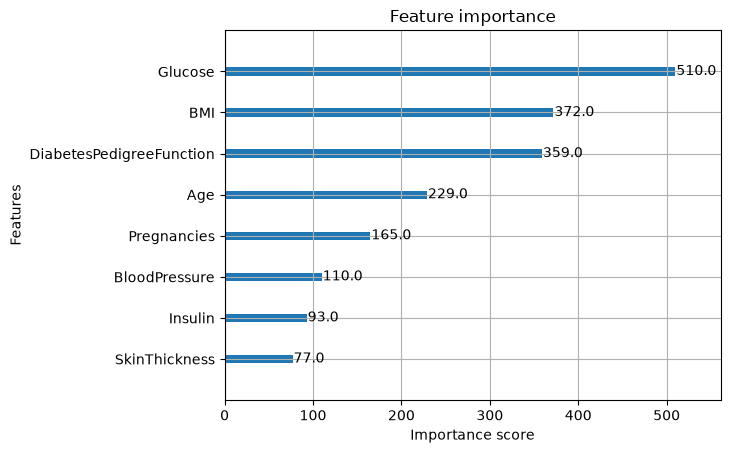

In [16]:
opt.best_estimator_.steps
from xgboost import plot_importance
xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model)

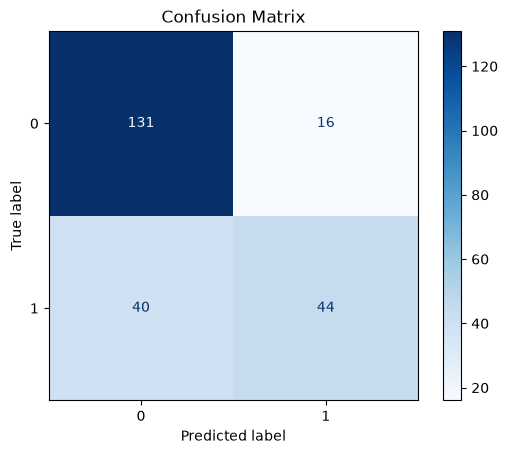

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = opt.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

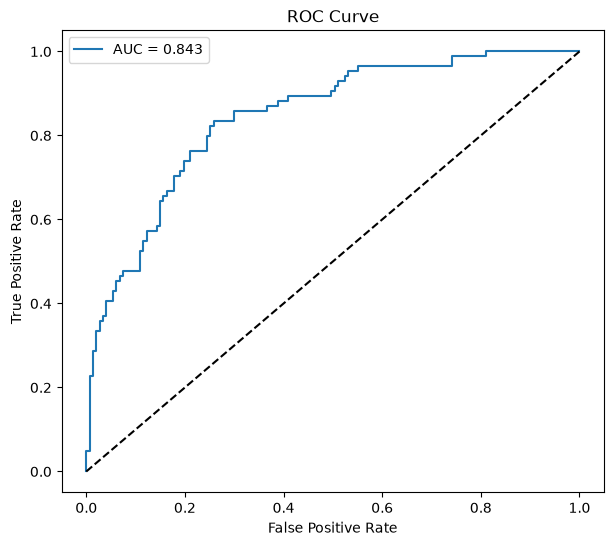

In [18]:
from sklearn.metrics import roc_curve, auc

y_prob = opt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

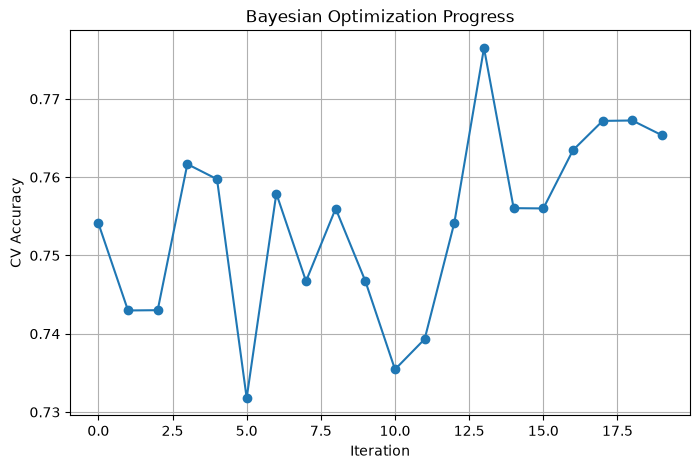

In [19]:
results = opt.cv_results_

plt.figure(figsize=(8,5))
plt.plot(results['mean_test_score'], marker='o')
plt.xlabel("Iteration")
plt.ylabel("CV Accuracy")
plt.title("Bayesian Optimization Progress")
plt.grid(True)
plt.show()

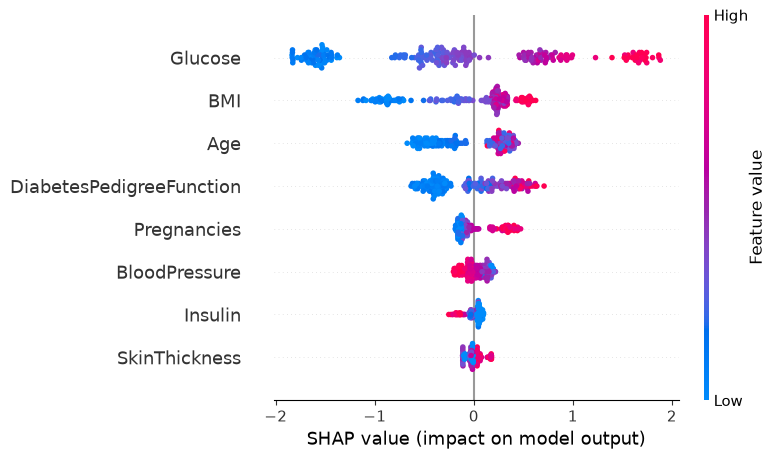

In [21]:
import shap

model = opt.best_estimator_.named_steps['clf']

encoder = opt.best_estimator_.named_steps['encoder']
X_train_enc = encoder.transform(X_train)
X_test_enc = encoder.transform(X_test)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_enc)

shap.summary_plot(shap_values, X_test_enc)

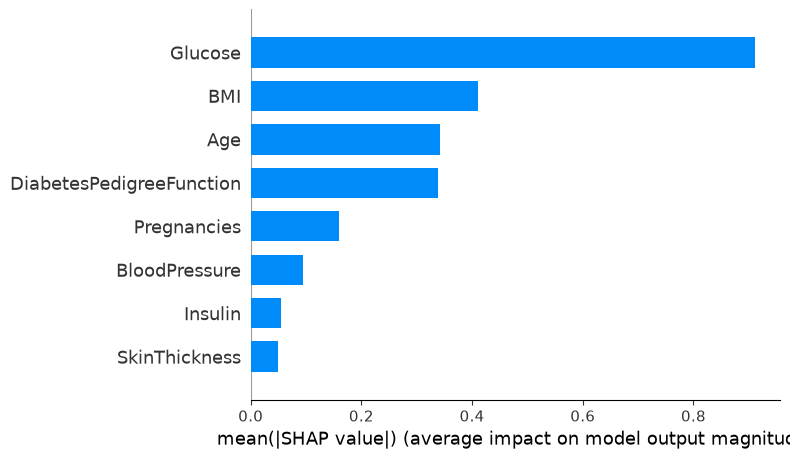

In [22]:
shap.summary_plot(
    shap_values,
    X_test_enc,
    plot_type="bar"
)